In [1]:
import scanpy as sc
import anndata as ad
import os
import pandas as pd
import gc
import numpy as np
from scipy.sparse import csr_matrix
os.chdir('/ictstr01/groups/ml01/workspace/hpca/data/')

In [2]:
class Concat:
    def __init__(self, base_path, output_file, dataset_name, extension, index_number='1'):
        self.base_path = base_path
        self.output_file = output_file
        self.dataset_name = dataset_name
        self.extension = extension
        self.index_number = index_number
        self.ann_data_list = []
        self.process_directories()
        
    def process_directories(self):
        highly_variable_genes = None 
        for root, dirs, files in os.walk(self.base_path):
            for file in files:
                if file.endswith(self.extension):
                    file_path = os.path.join(root, file)
                    print(f"Loading Anndata: {file_path}")
                    adata = self.load_anndata(file_path)
                    print("Adding Metadata")
                    # print(file_path)
                    self.add_metadata(adata, file_path)
                    self.ann_data_list.append(adata)
        print(self.ann_data_list)            
        print('Concatinating Datasets')
        self.concat_and_save()

    def load_anndata(self, file_path):
        return sc.read_h5ad(file_path)

    def add_metadata(self, adata, file_path):
        # print(file_path)
        print('Changing Var Index')
        if '1' in adata.var:
            adata.var[self.index_number] = adata.var[self.index_number].astype(str)
            adata.var.index = adata.var['1']
        adata.var_names_make_unique()
        adata.var['1'] = adata.var[self.index_number].astype(str)
        # Extracting directory name from the path
        # directory_name = os.path.basename(directory_name)
        file_name = os.path.basename(file_path).split('.')[0]
        print(f"Adding ID for {file_name}")
        # Adding columns to adata.obs
        adata.obs['ID'] = file_name
        adata.obs['Dataset'] = self.dataset_name
    
    def concat_and_save(self):
        if self.ann_data_list:
            concatenated_anndata = ad.concat(self.ann_data_list, join='outer', fill_value=0)
            concatenated_anndata.obs = concatenated_anndata.obs.astype(str)
            concatenated_anndata.var = concatenated_anndata.var.astype(str)
            concatenated_anndata.write_h5ad(self.output_file)


# GSE183568

In [3]:
facs = sc.read_h5ad('GSE183568/GSE183568_FACS_raw_gene_cell_counts.h5ad')
adata = sc.read_h5ad('GSE183568/GSE183568_raw_gene_cell_counts.h5ad')

In [4]:
metadata_txt = pd.read_table('GSE183568/GSE183568_scRNAseq_metadata.txt')
facs_txt = pd.read_table('GSE183568/GSE183568_FACS_scRNAseq_metadata.txt')

In [5]:
adata.obs.set_index('sample', inplace=True)
facs.obs.set_index('sample', inplace=True)

In [6]:
facs_txt.rename(columns={'LibraryID': 'Library_ID', 'CellType' : 'CellTypes'}, inplace=True)

In [7]:
adata.obs = adata.obs.join(metadata_txt, how='left')
facs.obs = facs.obs.join(facs_txt, how='left')
facs.obs['ID'] = 'GSE183568_FACS'
adata.obs['ID'] = 'GSE183568'
adata.obs['Dataset'] = 'GSE183568'
facs.obs['Dataset'] = 'GSE183568'

In [13]:
adata.X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [14]:
# Check if counts is raw 
for i in [adata,facs]:
    raw_counts = i.X
    print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")
    
    # Check some basic statistics
    print(f"Mean raw counts: {np.mean(raw_counts)}")
    print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
    print(f"Percentage of zero counts: {np.mean(raw_counts == 0) * 100:.2f}%")
    print("-" * 50)

Are raw counts integers? True
Mean raw counts: 0.3079597617995694
Range of raw counts: 0 to 15399
Percentage of zero counts: 91.35%
--------------------------------------------------
Are raw counts integers? True
Mean raw counts: 0.38383426535638066
Range of raw counts: 0 to 14829
Percentage of zero counts: 90.42%
--------------------------------------------------


In [16]:
csr_matrix(adata.X)   

<44953x26107 sparse matrix of type '<class 'numpy.int64'>'
	with 101462017 stored elements in Compressed Sparse Row format>

In [19]:
for i in [adata,facs]:
    i.layers['raw'] = csr_matrix(i.X).copy()

In [20]:
adata_concat = ad.concat([adata,facs], join='outer', fill_value=0)

In [21]:
adata_concat.write('GSE183568/GSE183568_concat.h5ad')

In [25]:
adata_concat.layers['raw']

<55275x26210 sparse matrix of type '<class 'numpy.int64'>'
	with 125260936 stored elements in Compressed Sparse Row format>

In [26]:
raw_counts = adata_concat.layers['raw'].toarray()
print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")

# Check some basic statistics
print(f"Mean raw counts: {np.mean(raw_counts)}")
print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
print(f"Percentage of zero counts: {np.mean(raw_counts == 0) * 100:.2f}%")
print("-" * 50)

Are raw counts integers? True
Mean raw counts: 0.31527010433593883
Range of raw counts: 0 to 15399
Percentage of zero counts: 91.35%
--------------------------------------------------


In [27]:
del adata
del facs
del adata_concat
gc.collect()

1419

In [39]:
# GSE183568 has cell types

# GSE198623

In [66]:
adata = sc.read_h5ad('GSE198623/GSE198623_human_processed.h5ad')

In [68]:
adata.raw.X

<26474x32738 sparse matrix of type '<class 'numpy.float32'>'
	with 83444887 stored elements in Compressed Sparse Row format>

In [69]:
adata.obs.rename(columns={'id': 'ID'}, inplace=True)
adata.obs['CellTypes'] = adata.obs.louvain_anno_fine
adata.obs['Dataset'] = 'GSE198623'

In [14]:
raw_counts = adata.X.toarray()
print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")

# Check some basic statistics
print(f"Mean raw counts: {np.mean(raw_counts)}")
print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
print(f"Percentage of zero counts: {np.mean(raw_counts == 0) * 100:.2f}%")
print("-" * 50)

Are raw counts integers? False
Mean raw counts: 0.10963678359985352
Range of raw counts: -0.3923165202140808 to 22.239540100097656
Percentage of zero counts: 90.38%
--------------------------------------------------


In [71]:
adata.layers['raw'] = adata.raw.X.copy()

In [15]:
adata.X = adata.layers['raw'].copy()

In [16]:
raw_counts = adata.X.toarray()
print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")

# Check some basic statistics
print(f"Mean raw counts: {np.mean(raw_counts)}")
print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
print(f"Percentage of zero counts: {np.mean(raw_counts == 0) * 100:.2f}%")
print("-" * 50)

Are raw counts integers? True
Mean raw counts: 0.5317429304122925
Range of raw counts: 0.0 to 32598.0
Percentage of zero counts: 90.37%
--------------------------------------------------


In [72]:
adata

AnnData object with n_obs × n_vars = 26474 × 32738
    obs: 'sample', 'louvain_anno_broad', 'louvain_anno_fine', 'ID', 'BMI', 'HbA1c', 'insulin_content', 'glucose_SI', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'organism_ontolology_term_id', 'disease_ontology_term_id', 'ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'n_genes', 'n_counts', 'mt_frac', 'size_factors', 'CellTypes', 'Dataset'
    var: 'feature_is_filtered', 'feature_biotype'
    uns: 'X_normalization', 'batch_condition', 'default_embedding', 'schema_version', 'title'
    obsm: 'X_pca', 'X_umap'
    layers: 'raw'

In [17]:
adata.write('GSE198623/GSE198623_processed_raw_concat.h5ad')

In [18]:
adata = sc.read_h5ad('GSE198623/GSE198623_processed_raw_concat.h5ad')

In [24]:
adata

AnnData object with n_obs × n_vars = 26474 × 32738
    obs: 'sample', 'louvain_anno_broad', 'louvain_anno_fine', 'ID', 'BMI', 'HbA1c', 'insulin_content', 'glucose_SI', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'organism_ontolology_term_id', 'disease_ontology_term_id', 'ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'n_genes', 'n_counts', 'mt_frac', 'size_factors', 'CellTypes', 'Dataset'
    var: 'feature_is_filtered', 'feature_biotype'
    uns: 'X_normalization', 'batch_condition', 'default_embedding', 'schema_version', 'title'
    obsm: 'X_pca', 'X_umap'
    layers: 'raw'

In [21]:
test = sc.read_h5ad('GSE198623/GSE198623_processed_concat.h5ad')

/home/aih/shrey.parikh/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [36]:
raw_counts = test.X.toarray()
print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")

# Check some basic statistics
print(f"Mean raw counts: {np.mean(raw_counts)}")
print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
print(f"Percentage of zero counts: {np.mean(raw_counts == 0) * 100:.2f}%")
print("-" * 50)

Are raw counts integers? True
Mean raw counts: 0.7113540041773495
Range of raw counts: 0 to 32598
Percentage of zero counts: 87.27%
--------------------------------------------------


In [39]:
test.layers['raw'] = test.X.copy()

In [42]:
test.obs_names_make_unique()
test.var_names = test.var_names.astype(str)
test.var_names_make_unique()

In [47]:
test.var = test.var.astype(str)
test.obs = test.obs.astype(str)

In [50]:
test.var.rename(columns={'gene_id': 'Gene_ID'}, inplace=True)

In [51]:
test.write('GSE198623/GSE198623_processed_raw_final_concat.h5ad')

In [27]:
test.var.gene_id.isna().sum()

0

In [97]:
adata.obs_names_make_unique()
adata.var_names_make_unique()

In [42]:
del adata
gc.collect()

24

## nothing needs to be done
## GSE198623 has cell types

# GSE217837

## not used
## no raw counts

In [56]:
csv = pd.read_csv('GSE217837/GSE217837_scRNA_count_matrix.csv', index_col='Unnamed: 0')

In [83]:
csv

,AAACCCAAGGATATGT.1_1,AAACCCACACAAATAG.1_1,AAACCCACAGACCAGA.1_1,AAACCCAGTCGCACGT.1_1,AAACCCAGTCTGTAAC.1_1,AAACCCATCCTAGCCT.1_1,AAACGAAGTCATGACT.1_1,AAACGAATCATTGCGA.1_1,AAACGAATCCCATAGA.1_1,AAACGAATCGTGTCAA.1_1,...,TTTGGAGGTGGAAGTC.1_3,TTTGGTTAGCCAACCC.1_3,TTTGGTTAGCGACTTT.1_3,TTTGGTTCATCATTGG.1_3,TTTGGTTGTAGCTTTG.1_3,TTTGGTTGTCTAGTGT.1_3,TTTGGTTTCACTGTCC.1_3,TTTGGTTTCATTCCTA.1_3,TTTGTTGTCAAATAGG.1_3,TTTGTTGTCTACAGGT.1_3
AL627309.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
AL627309.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
AL627309.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
LINC01409,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.751636,0.0
FAM87B,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MLC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
CYLC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
RHOXF2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
NLGN4Y-AS1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


In [84]:
# Check if counts is raw 
raw_counts = csv.values.flatten()
print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")

# Check some basic statistics
print(f"Mean raw counts: {np.mean(raw_counts)}")
print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
print(f"Percentage of zero counts: {np.mean(raw_counts == 0) * 100:.2f}%")
print("-" * 50)

Are raw counts integers? False
Mean raw counts: 0.3382771467841355
Range of raw counts: 0.0 to 26646.9087653726
Percentage of zero counts: 91.11%
--------------------------------------------------


In [50]:
adata = sc.read_h5ad('GSE217837/GSE217837_scRNA_count_matrix.h5ad')

In [51]:
sn = sc.read_h5ad('GSE217837/GSE217837_snRNA_count_matrix.h5ad')

In [81]:
adata.X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [52]:
adata.obs.set_index('sample', inplace=True)

In [53]:
sn.obs.set_index('sample', inplace=True)

In [54]:
adata.obs['ID'] = 'GSE217837_scRNA-seq'
adata.obs['Dataset'] = 'GSE217837_scRNA-seq'

In [55]:
sn.obs['ID'] = 'GSE217837_snRNA-seq'
sn.obs['Dataset'] = 'GSE217837_snRNA-seq'

In [58]:
# Check if counts is raw 
for i in [adata,sn]:
    raw_counts = i.X
    print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")
    
    # Check some basic statistics
    print(f"Mean raw counts: {np.mean(raw_counts)}")
    print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
    print(f"Percentage of zero counts: {np.mean(raw_counts == 0) * 100:.2f}%")
    print("-" * 50)

Are raw counts integers? False
Mean raw counts: 0.3382771467841356
Range of raw counts: 0.0 to 26646.9087653726
Percentage of zero counts: 91.11%
--------------------------------------------------
Are raw counts integers? False
Mean raw counts: 0.15318258623278788
Range of raw counts: 0.0 to 11536.5679036396
Percentage of zero counts: 92.02%
--------------------------------------------------


In [56]:
adata_concat = ad.concat([adata,sn], join='outer', fill_value=0)

In [59]:
adata_concat.write('GSE217837/GSE217837_concat.h5ad')

In [60]:
## no cell type labels
## no raw counts

In [65]:
del adata_concat
del adata
del sn
gc.collect()

3198

# GSE84133_remapped

In [64]:
pwd

'/ictstr01/groups/ml01/workspace/hpca/data'

In [70]:
test = sc.read_h5ad('GSE84133_remapped/GSM2230757_GeneFull_filtered.h5ad')

In [74]:
test.var

,0,1,2
0,ENSG00000243485,MIR1302-2HG,Gene Expression
1,ENSG00000237613,FAM138A,Gene Expression
2,ENSG00000186092,OR4F5,Gene Expression
3,ENSG00000238009,AL627309.1,Gene Expression
4,ENSG00000239945,AL627309.3,Gene Expression
...,...,...,...
36596,ENSG00000277836,AC141272.1,Gene Expression
36597,ENSG00000278633,AC023491.2,Gene Expression
36598,ENSG00000276017,AC007325.1,Gene Expression
36599,ENSG00000278817,AC007325.4,Gene Expression


In [121]:
GSE84133_remapped = Concat(base_path='GSE84133_remapped', output_file='GSE84133_remapped/GSE84133_remapped_concat.h5ad', dataset_name='GSE84133_remapped',extension='GeneFull_filtered.h5ad')

Loading Anndata: GSE84133_remapped/GSM2230759_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM2230759_GeneFull_filtered
Loading Anndata: GSE84133_remapped/GSM2230757_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM2230757_GeneFull_filtered
Loading Anndata: GSE84133_remapped/GSM2230758_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM2230758_GeneFull_filtered
Loading Anndata: GSE84133_remapped/GSM2230761_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM2230761_GeneFull_filtered
Loading Anndata: GSE84133_remapped/GSM2230760_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM2230760_GeneFull_filtered
Loading Anndata: GSE84133_remapped/GSM2230762_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM2230762_GeneFull_filtered
[AnnData object with n_obs × n_vars = 4178 × 36601
    obs: 'ID', 'Dataset'
    var: '0', '1', '2', AnnData object wit

/home/aih/shrey.parikh/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [28]:
adata = sc.read_h5ad('GSE84133_remapped/GSE84133_remapped_concat.h5ad')

In [29]:
# only 57,58,59,60 are human for gse_133
list_human = ['GSM2230759_GeneFull_filtered', 'GSM2230757_GeneFull_filtered', 'GSM2230758_GeneFull_filtered', 'GSM2230760_GeneFull_filtered']

In [32]:
adata = adata[adata.obs.ID.isin(list_human)]

In [33]:
adata.obs_names_make_unique()
adata.var_names_make_unique()

In [34]:
adata.layers['raw'] = adata.X.copy()

In [35]:
adata.write('GSE84133_remapped/GSE84133_remapped_human_concat.h5ad')

In [67]:
del test
del adata
gc.collect()

2315

In [125]:
# no cell type labels

# Tabula Sapiens

In [128]:
test = sc.read_h5ad('Tabula_Sapiens/TSP1_endopancreas_1_GeneFull_filtered.h5ad')

In [131]:
test.var

,0,1,2
0,ENSG00000243485,MIR1302-2HG,Gene Expression
1,ENSG00000237613,FAM138A,Gene Expression
2,ENSG00000186092,OR4F5,Gene Expression
3,ENSG00000238009,AL627309.1,Gene Expression
4,ENSG00000239945,AL627309.3,Gene Expression
...,...,...,...
36596,ENSG00000277836,AC141272.1,Gene Expression
36597,ENSG00000278633,AC023491.2,Gene Expression
36598,ENSG00000276017,AC007325.1,Gene Expression
36599,ENSG00000278817,AC007325.4,Gene Expression


In [132]:
ts = Concat(base_path='Tabula_Sapiens', output_file='Tabula_Sapiens/Tabula_Sapiens_GeneFull_filtered_concat.h5ad', dataset_name='Tabula_Sapiens',extension='GeneFull_filtered.h5ad')

Loading Anndata: Tabula_Sapiens/TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_GeneFull_filtered
Loading Anndata: Tabula_Sapiens/TSP1_exopancreas2_1_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for TSP1_exopancreas2_1_GeneFull_filtered
Loading Anndata: Tabula_Sapiens/TSP1_exopancreas2_3_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for TSP1_exopancreas2_3_GeneFull_filtered
Loading Anndata: Tabula_Sapiens/TSP1_exopancreas1_1_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for TSP1_exopancreas1_1_GeneFull_filtered
Loading Anndata: Tabula_Sapiens/TSP1_exopancreas1_2_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for TSP1_exopancreas1_2_GeneFull_filtered
Loading Anndata: Tabula_Sapiens/TSP1_endopancreas_2_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for TSP1_endopancrea

/home/aih/shrey.parikh/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [68]:
adata = sc.read_h5ad('Tabula_Sapiens/Tabula_Sapiens_GeneFull_filtered_concat.h5ad')

In [136]:
adata.obs

,ID,Dataset
barcode,,
AAACCCAAGACATCAA,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens
AAACCCAAGCGCCGTT,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens
AAACCCAAGGGCAATC,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens
AAACCCAAGTGATAAC,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens
AAACCCACAATTCACG,TSP9_Pancreas_exocrine_10X_1_1_CellCountLive_G...,Tabula_Sapiens
...,...,...
TTTGGAGTCAAAGGTA,TSP1_endopancreas_3_GeneFull_filtered,Tabula_Sapiens
TTTGGTTCAGGCTACC,TSP1_endopancreas_3_GeneFull_filtered,Tabula_Sapiens
TTTGGTTTCCGTGTGG,TSP1_endopancreas_3_GeneFull_filtered,Tabula_Sapiens


In [47]:
adata.obs_names_make_unique()
adata.var_names_make_unique()

In [72]:
adata.layers['raw'] = adata.X.copy()

In [73]:
adata.write('Tabula_Sapiens/Tabula_Sapiens_GeneFull_filtered_concat.h5ad')

In [49]:
adata

AnnData object with n_obs × n_vars = 34299 × 36601
    obs: 'ID', 'Dataset'

# charite_snRNA

In [53]:
adata = sc.read_h5ad('charite_snRNA/adult_pancreas_2020.h5ad')

In [56]:
adata.obs.patient_ID.unique()

['AFES448', 'AFES365', 'AGBR024', 'TUM_13', 'TUM_25', 'TUM_C1']
Categories (6, object): ['AFES365', 'AFES448', 'AGBR024', 'TUM_13', 'TUM_25', 'TUM_C1']

In [143]:
adata.obs['ID'] = adata.obs.patient_ID
adata.obs['Dataset'] = 'charite_snRNA'
adata.obs['CellTypes'] = adata.obs.Cluster

In [151]:
# Raw in counts
adata.layers['raw'] = adata.layers['counts'].copy()

In [156]:
adata.shape

(112563, 43815)

In [150]:
adata_subset = sc.pp.subsample(adata, fraction=0.1, copy=True)
raw_counts = adata_subset.layers['counts'].toarray()
print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")
print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
print("-" * 50)

Are raw counts integers? True
Range of raw counts: 0.0 to 4889.0
--------------------------------------------------


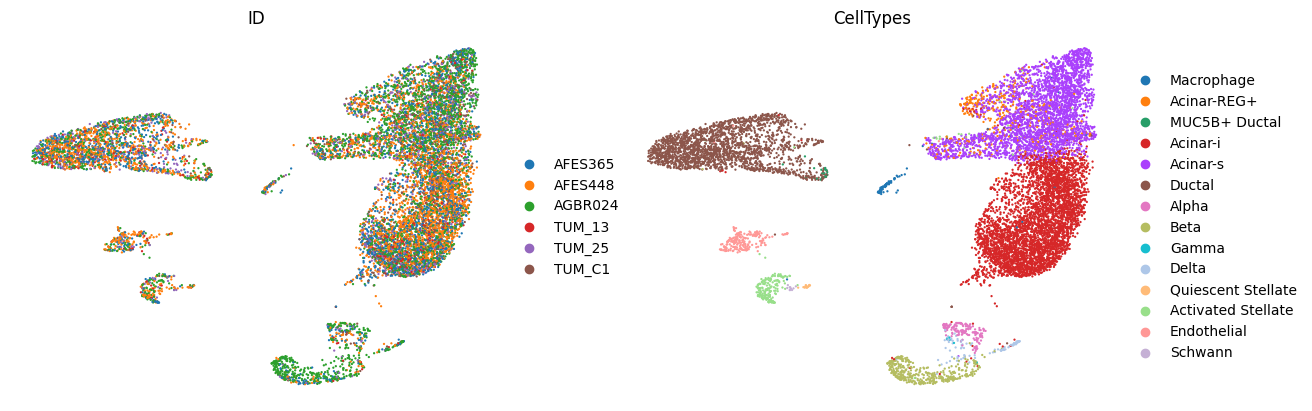

In [153]:
sc.pl.umap(adata_subset, color=['ID', 'CellTypes'], frameon=False)

In [157]:
# contains cell type labels
adata.write('charite_snRNA/charite_adult_pancreas_concat.h5ad')

In [4]:
adata = sc.read_h5ad('charite_snRNA/charite_adult_pancreas_concat.h5ad')

In [10]:
# Check if counts is raw 
# raw in counts
adata_subset = sc.pp.subsample(adata, fraction=0.1, copy=True)
raw_counts = adata_subset.X.toarray()
print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")
# Check some basic statistics
print(f"Mean raw counts: {np.mean(raw_counts)}")
print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
print(f"Percentage of zero counts: {np.mean(raw_counts == 0) * 100:.2f}%")
print("-" * 50)

Are raw counts integers? True
Mean raw counts: 0.029492320517041145
Range of raw counts: 0.0 to 4889.0
Percentage of zero counts: 98.41%
--------------------------------------------------


In [9]:
adata.X = adata.layers['raw'].copy()

In [11]:
adata.write('charite_snRNA/charite_adult_pancreas_concat.h5ad')

In [12]:
del adata
gc.collect()

449

# GSE101207_remapped

In [161]:
test = sc.read_h5ad('GSE101207_remapped/GSM2700338_GeneFull_filtered.h5ad')

In [165]:
test.var

,0,1,2
0,ENSG00000243485,MIR1302-2HG,Gene Expression
1,ENSG00000237613,FAM138A,Gene Expression
2,ENSG00000186092,OR4F5,Gene Expression
3,ENSG00000238009,AL627309.1,Gene Expression
4,ENSG00000239945,AL627309.3,Gene Expression
...,...,...,...
36596,ENSG00000277836,AC141272.1,Gene Expression
36597,ENSG00000278633,AC023491.2,Gene Expression
36598,ENSG00000276017,AC007325.1,Gene Expression
36599,ENSG00000278817,AC007325.4,Gene Expression


In [166]:
GSE101207_remapped = Concat(base_path='GSE101207_remapped', output_file='GSE101207_remapped/GSE101207_remapped_GeneFull_filtered_concat.h5ad', dataset_name='GSE101207_remapped',extension='GeneFull_filtered.h5ad')

Loading Anndata: GSE101207_remapped/GSM2700343_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM2700343_GeneFull_filtered
Loading Anndata: GSE101207_remapped/GSM2863188_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM2863188_GeneFull_filtered
Loading Anndata: GSE101207_remapped/GSM2700344_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM2700344_GeneFull_filtered
Loading Anndata: GSE101207_remapped/GSM2863189_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM2863189_GeneFull_filtered
Loading Anndata: GSE101207_remapped/GSM2700339_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM2700339_GeneFull_filtered
Loading Anndata: GSE101207_remapped/GSM2700342_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM2700342_GeneFull_filtered
Loading Anndata: GSE101207_remapped/GSM2700338_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding 

/home/aih/shrey.parikh/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [74]:
adata = sc.read_h5ad('GSE101207_remapped/GSE101207_remapped_GeneFull_filtered_concat.h5ad')

In [34]:
adata.obs_names_make_unique()
adata.var_names_make_unique()

In [75]:
adata.layers['raw'] = adata.X.copy()

In [76]:
adata.write('GSE101207_remapped/GSE101207_remapped_GeneFull_filtered_concat.h5ad')

In [37]:
# no cell type labels
del adata
del test
gc.collect()

1837

# GSE114297_remapped

In [172]:
test = sc.read_h5ad('GSE114297_remapped/GSM3138939_GeneFull_filtered.h5ad')

In [175]:
test.var

,0,1,2
0,ENSG00000243485,MIR1302-2HG,Gene Expression
1,ENSG00000237613,FAM138A,Gene Expression
2,ENSG00000186092,OR4F5,Gene Expression
3,ENSG00000238009,AL627309.1,Gene Expression
4,ENSG00000239945,AL627309.3,Gene Expression
...,...,...,...
36596,ENSG00000277836,AC141272.1,Gene Expression
36597,ENSG00000278633,AC023491.2,Gene Expression
36598,ENSG00000276017,AC007325.1,Gene Expression
36599,ENSG00000278817,AC007325.4,Gene Expression


In [176]:
GSE114297_remapped = Concat(base_path='GSE114297_remapped', output_file='GSE114297_remapped/GSE114297_remapped_GeneFull_filtered_concat.h5ad', dataset_name='GSE114297_remapped',extension='GeneFull_filtered.h5ad')

Loading Anndata: GSE114297_remapped/GSM3138944_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM3138944_GeneFull_filtered
Loading Anndata: GSE114297_remapped/GSM3138939_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM3138939_GeneFull_filtered
Loading Anndata: GSE114297_remapped/GSM3138946_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM3138946_GeneFull_filtered
Loading Anndata: GSE114297_remapped/GSM3138950_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM3138950_GeneFull_filtered
Loading Anndata: GSE114297_remapped/GSM3138941_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM3138941_GeneFull_filtered
Loading Anndata: GSE114297_remapped/GSM3138943_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding ID for GSM3138943_GeneFull_filtered
Loading Anndata: GSE114297_remapped/GSM3138945_GeneFull_filtered.h5ad
Adding Metadata
Changing Var Index
Adding 

/home/aih/shrey.parikh/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [77]:
adata = sc.read_h5ad('GSE114297_remapped/GSE114297_remapped_GeneFull_filtered_concat.h5ad')

In [41]:
adata

AnnData object with n_obs × n_vars = 28595 × 36601
    obs: 'ID', 'Dataset'

In [40]:
adata.obs_names_make_unique()
adata.var_names_make_unique()

In [78]:
adata.layers['raw'] = adata.X.copy()

In [79]:
adata.write('GSE114297_remapped/GSE114297_remapped_GeneFull_filtered_concat.h5ad')

In [180]:
# no cell type labels
del adata
del test
gc.collect()

218

# GSE150724

In [182]:
test = sc.read_h5ad('GSE150724/Donor1_output.h5ad')

In [185]:
test.obs

""
barcode
AAACCCAAGACATATG_d1_ge
AAACCCACATTGTCGA_d1_ge
AAACGAAAGAAGTATC_d1_ge
AAACGAAGTAATCAGA_d1_ge
AAACGAAGTACTGAGG_d1_ge
...
TTTGATCCAAACTCGT_d1_d
TTTGATCTCCAGCCTT_d1_d
TTTGATCTCCCTTGTG_d1_d


In [187]:
GSE150724 = Concat(base_path='GSE150724', output_file='GSE150724/GSE150724_GeneFull_filtered_concat.h5ad', dataset_name='GSE150724',extension='output.h5ad', index_number='0')

Loading Anndata: GSE150724/Donor3_output.h5ad
Adding Metadata
Changing Var Index
Adding ID for Donor3_output
Loading Anndata: GSE150724/Donor1_output.h5ad
Adding Metadata
Changing Var Index
Adding ID for Donor1_output
Loading Anndata: GSE150724/Donor2_output.h5ad
Adding Metadata
Changing Var Index
Adding ID for Donor2_output
[AnnData object with n_obs × n_vars = 935 × 33538
    obs: 'ID', 'Dataset'
    var: '0', '1', AnnData object with n_obs × n_vars = 7788 × 33538
    obs: 'ID', 'Dataset'
    var: '0', '1', AnnData object with n_obs × n_vars = 6764 × 33538
    obs: 'ID', 'Dataset'
    var: '0', '1']
Concatinating Datasets


# changed by Daniel
# loading the new file

In [81]:
adata = sc.read_h5ad('GSE150724/GSE150724_GeneFull_filtered_new_concat.h5ad')

In [85]:
adata_subset = sc.pp.subsample(adata, fraction=0.1, copy=True)
raw_counts = adata_subset.X.toarray()
print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")
# Check some basic statistics
print(f"Mean raw counts: {np.mean(raw_counts)}")
print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
print(f"Percentage of zero counts: {np.mean(raw_counts == 0) * 100:.2f}%")
print("-" * 50)

Are raw counts integers? True
Mean raw counts: 0.4079010495711371
Range of raw counts: 0 to 44428
Percentage of zero counts: 90.73%
--------------------------------------------------


In [86]:
adata.layers['raw'] = adata.X.copy()

In [88]:
adata.write('GSE150724/GSE150724_GeneFull_filtered_new_concat.h5ad')

In [192]:
# no cell type labels
del adata
del test
gc.collect()

1622

# espace

In [3]:
## redone on 13/09/2024
## redone on 04/03/2025 - problem due to CB assay, taken RNA assay final

In [6]:
os.chdir('datasets/')

In [7]:
cultured_islets = sc.read_h5ad('espace/scRNA_cultured_islets_allcells_ND-healthy_20240118_rawcounts.h5ad')

In [8]:
frozen_islets_healthy = sc.read_h5ad('espace/snRNA_frozen_islets_allcells_healthy_20240118_rawcounts.h5ad')
adult_whole = sc.read_h5ad('espace/snRNA_adult_whole_pancreas_allcells_healthy_RNA_20250304.h5ad')

In [9]:
for adata,i in zip([cultured_islets, frozen_islets_healthy, adult_whole], ['espace_scRNA_cultured_islets', 'espace_snRNA_frozen_islets', 'espace_snRNA_adult_whole']):
    adata.obs['ID'] = adata.obs.patient_id
    adata.obs['Dataset'] = i
    annot_col = adata.obs.columns[adata.obs.columns.str.contains('annotation_l2')][0]
    print(annot_col)
    adata.obs['CellTypes'] = adata.obs[annot_col]
    adata.obs = adata.obs.rename(columns=lambda x: x + '_espace' if x.startswith('annotation') else x)

annotation_l2
annotation_l2
annotation_l2


In [10]:
# Check if counts is raw 
# raw in counts
for i in [cultured_islets, frozen_islets_healthy]: #, adult_whole]:
    adata_subset = sc.pp.subsample(i, fraction=0.1, copy=True)
    raw_counts = adata_subset.layers['counts'].toarray()
    print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")
    # Check some basic statistics
    print(f"Mean raw counts: {np.mean(raw_counts)}")
    print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
    print(f"Percentage of zero counts: {np.mean(raw_counts == 0) * 100:.2f}%")
    print("-" * 50)

Are raw counts integers? True
Mean raw counts: 0.44906682935964737
Range of raw counts: 0.0 to 23584.0
Percentage of zero counts: 88.04%
--------------------------------------------------
Are raw counts integers? True
Mean raw counts: 0.28107499932843827
Range of raw counts: 0.0 to 11795.0
Percentage of zero counts: 90.80%
--------------------------------------------------


In [11]:
adata_subset = sc.pp.subsample(adult_whole, fraction=0.1, copy=True)
raw_counts = adata_subset.X.toarray()
print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")
# Check some basic statistics
print(f"Mean raw counts: {np.mean(raw_counts)}")
print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
print(f"Percentage of zero counts: {np.mean(raw_counts == 0) * 100:.2f}%")
print("-" * 50)

Are raw counts integers? True
Mean raw counts: 0.11482021687993203
Range of raw counts: 0.0 to 3971.0
Percentage of zero counts: 94.95%
--------------------------------------------------


In [12]:
adult_whole.layers['raw'] = adult_whole.X.copy()

In [13]:
cultured_islets.layers['raw'] = cultured_islets.layers['counts'].copy()
cultured_islets.X = cultured_islets.layers['raw'].copy()

In [14]:
frozen_islets_healthy.layers['raw'] = frozen_islets_healthy.layers['counts'].copy()
frozen_islets_healthy.X = frozen_islets_healthy.layers['raw'].copy()

In [7]:
# l2 taken as celltypes

In [15]:
adata_concat = ad.concat([cultured_islets, frozen_islets_healthy, adult_whole], join='outer', fill_value=0)

In [17]:
adata_concat.obs.columns[adata_concat.obs.columns.str.contains('annotation')]

Index(['annotation_l1_espace', 'annotation_l2_espace', 'annotation_l3_espace',
       'annotation_l4_espace', 'annotation_l2_reduced_espace',
       'tt_annotation_l1', 'tt_annotation_l2', 'tt_annotation_l3',
       'tt_annotation_l4'],
      dtype='object')

In [18]:
cols_to_keep = ['annotation_l1_espace', 'annotation_l2_espace', 'annotation_l3_espace', 'annotation_l4_espace', 'Dataset', 'ID', 'espace_id', 'CellTypes']

In [19]:
adata_concat.obs = adata_concat.obs[cols_to_keep].copy()

In [16]:
adata_subset = sc.pp.subsample(adata_concat, fraction=0.1, copy=True)
raw_counts = adata_subset.X.toarray()
print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")
# Check some basic statistics
print(f"Mean raw counts: {np.mean(raw_counts)}")
print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
print(f"Percentage of zero counts: {np.mean(raw_counts == 0) * 100:.2f}%")
print("-" * 50)

Are raw counts integers? True
Mean raw counts: 0.15487850727660848
Range of raw counts: 0.0 to 23651.0
Percentage of zero counts: 94.10%
--------------------------------------------------


In [20]:
adata_concat

AnnData object with n_obs × n_vars = 513176 × 36601
    obs: 'annotation_l1_espace', 'annotation_l2_espace', 'annotation_l3_espace', 'annotation_l4_espace', 'Dataset', 'ID', 'espace_id', 'CellTypes'
    obsm: 'X_harmony', 'X_pca', 'X_umap', 'HARMONY', 'HARMONY_CB', 'PCA', 'PCA_CB', 'UMAP', 'UMAP_OLD'
    layers: 'counts', 'raw', 'logcounts'

In [21]:
adata_concat.write('espace/espace_04032025_concat.h5ad')

In [36]:
# cell type label present
del adata_concat
del cultured_islets
del frozen_islets_healthy
del adult_whole
gc.collect()

4595

# GSE148073

## weird h5 files
## part of HPAP

# HPAP

In [89]:
adata = sc.read_h5ad('HPAP/hpap_islet_scRNAseq.h5ad')

In [7]:
adata

AnnData object with n_obs × n_vars = 192203 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'Percent MT', 'Seurat Clusters', 'Library', 'Sex', 'Diabetes Status', 'Tissue Source', 'Chemistry', 'Cell Type', 'Cell Type Grouped'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    layers: 'counts'

In [8]:
adata_subset = sc.pp.subsample(adata, fraction=0.1, copy=True)
raw_counts = adata_subset.layers['counts'].toarray()
print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")
print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
print("-" * 50)

Are raw counts integers? True
Range of raw counts: 0.0 to 142047.0
--------------------------------------------------


In [9]:
raw_counts = adata_subset.X.toarray()
print(f"Are raw counts integers? {np.all(raw_counts.astype(int) == raw_counts)}")
print(f"Range of raw counts: {np.min(raw_counts)} to {np.max(raw_counts)}")
print("-" * 50)

Are raw counts integers? False
Range of raw counts: 0.0 to 9.053699493408203
--------------------------------------------------


In [10]:
adata.layers['raw'] = adata.layers['counts'].copy()

In [12]:
adata.obs['ID'] = adata.obs.Library
adata.obs['Dataset'] = 'HPAP'
adata.obs['CellTypes'] = adata.obs['Cell Type']

In [17]:
adata.obs

,nCount_RNA,nFeature_RNA,Percent MT,Seurat Clusters,Library,Sex,Diabetes Status,Tissue Source,Chemistry,Cell Type,Cell Type Grouped,ID,Dataset,CellTypes
HPAP-019_AAACCTGAGGCGCTCT-1,17017.0,2811,6.017512,3,HPAP-019,M,AAB+,nPod,10Xv2,Beta,Beta,HPAP-019,HPAP,Beta
HPAP-019_AAACCTGAGTTACCCA-1,8514.0,2037,2.666197,3,HPAP-019,M,AAB+,nPod,10Xv2,Beta,Beta,HPAP-019,HPAP,Beta
HPAP-019_AAACCTGAGTTCGCAT-1,28541.0,4455,5.115448,3,HPAP-019,M,AAB+,nPod,10Xv2,Beta,Beta,HPAP-019,HPAP,Beta
HPAP-019_AAACCTGCACGCGAAA-1,23547.0,4381,6.221599,3,HPAP-019,M,AAB+,nPod,10Xv2,Beta,Beta,HPAP-019,HPAP,Beta
HPAP-019_AAACCTGCATATACGC-1,51738.0,5576,4.163284,3,HPAP-019,M,AAB+,nPod,10Xv2,Beta,Beta,HPAP-019,HPAP,Beta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HPAP-109_TTTGTTGCAGTCTTCC-1,16349.0,4021,12.282097,4,HPAP-109,F,T2D,nPod,10Xv3,Ductal,Ductal,HPAP-109,HPAP,Ductal
HPAP-109_TTTGTTGCATGGGCAA-1,15027.0,3068,8.564584,2,HPAP-109,F,T2D,nPod,10Xv3,Acinar,Acinar,HPAP-109,HPAP,Acinar
HPAP-109_TTTGTTGGTAACAAGT-1,50451.0,6552,9.946285,4,HPAP-109,F,T2D,nPod,10Xv3,Ductal,Ductal,HPAP-109,HPAP,Ductal
HPAP-109_TTTGTTGGTCGTTGCG-1,37091.0,3799,3.761020,2,HPAP-109,F,T2D,nPod,10Xv3,Acinar,Acinar,HPAP-109,HPAP,Acinar


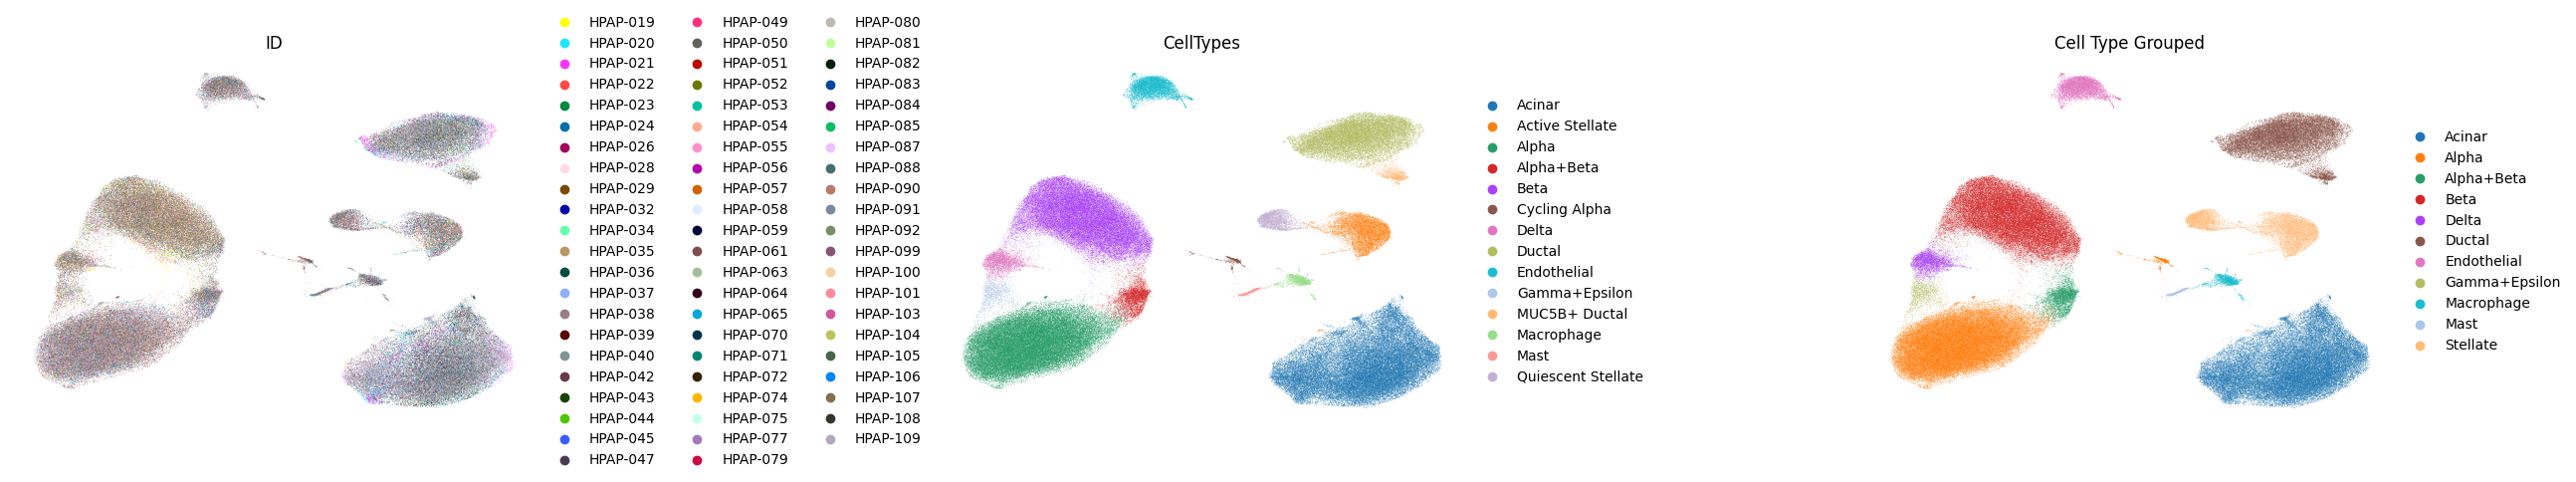

In [19]:
sc.pl.umap(adata, color=['ID', 'CellTypes', 'Cell Type Grouped'], frameon=False, wspace=0.6)

In [25]:
#cell type labels present
adata.write('HPAP/hpap_islet_scRNAseq_concat.h5ad')

In [92]:
adata = sc.read_h5ad(('HPAP/hpap_islet_scRNAseq_concat.h5ad'))

In [94]:
adata.X = adata.layers['raw'].copy()

In [95]:
adata.write('HPAP/hpap_islet_scRNAseq_concat.h5ad')

In [65]:
# Specify the directory to search in
files = []
paths = []
root_dir = '/ictstr01/groups/ml01/workspace/hpca/data'
count = 0
# Traverse the directory tree
for subdir in os.listdir(root_dir):
    count += 1
    if 'backup' in subdir:
        continue
    else:
        # print(subdir)
        path = os.path.join(root_dir, subdir)
        # print(path)
        for file in os.listdir(path):
            # print(file)
            if 'concat.h5ad' in file:
                # print(os.path.join(root_dir, subdir, file)) /
                paths.append(os.path.join(root_dir, subdir, file))
                files.append(file)
print(count)

14


In [66]:
(files)

['Tabula_Sapiens_GeneFull_filtered_concat.h5ad',
 'espace_concat.h5ad',
 'GSE183568_concat.h5ad',
 'GSE150724_GeneFull_filtered_concat.h5ad',
 'hpap_islet_scRNAseq_concat.h5ad',
 'GSE84133_remapped_concat.h5ad',
 'GSE198623_processed_concat.h5ad',
 'GSE217837_concat.h5ad',
 'GSE101207_remapped_GeneFull_filtered_concat.h5ad',
 'GSE114297_remapped_GeneFull_filtered_concat.h5ad',
 'charite_adult_pancreas_concat.h5ad']

In [68]:
len(paths)

11

# Karakose

In [4]:
karakose = sc.read_h5ad('karakose/dtl_seurat_counts_DMSO_integrated_harmony_lognormalize.h5ad')

In [12]:
obs_karakose = pd.read_csv('../data/data_shrey/karakose_obs (1).csv', index_col='Unnamed: 0')

In [17]:
karakose

AnnData object with n_obs × n_vars = 40743 × 27553
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor', 'treatment', 'percent_mt', 'integration_dataset_name', 'G2M.Score', 'S.Score', 'Phase', 'ident_resolution_0.2', 'ident_resolution_0.4', 'ident'
    uns: 'X_name'
    obsm: 'HARMONY', 'PCA', 'TSNE', 'UMAP'
    layers: 'logcounts', 'scaledata'

In [19]:
karakose.layers['counts'] = karakose.X.copy()

In [20]:
karakose.X = karakose.layers['logcounts']

In [21]:
karakose.layers['normcounts'] = karakose.layers['logcounts']

In [22]:
karakose.obs = obs_karakose

In [23]:
karakose.obs['Dataset'] = 'Karakose'
karakose.obs['ID'] = karakose.obs['orig.ident']

In [29]:
karakose.obs['celltype_all'] = karakose.obs.Manual_Annotation

In [30]:
del karakose.layers['scaledata']

In [ ]:
karakose.write_h5ad('karakose/karakose_concat.h5ad')

# Jimenez